# Homework 4

# Set-up

## Load libraries

In [21]:
library(ArchR)
library(parallel)
library(Seurat)

library(pryr) 
addArchRThreads(threads = 36)
set.seed(1)
addArchRGenome("mm10")
library(BSgenome.Mmusculus.UCSC.mm10)
# setwd("./arrowfiles/tutorialmm10")

Setting default number of Parallel threads to 36.

Setting default genome to Mm10.



## Load backup data

In [22]:
proj <- readRDS("backup8.rds")

# Peak Calling

> Did in first try, straight to results

## Find cell types to look at

In [23]:
table(proj$celltype)


Astro    CR    L4 L5 PT L6 IT   Sst 
  977   147   787   307  3086   150 

In [24]:
# proj$celltype <- proj$predictedsubGroup
# table(proj$celltype)
# valid_celltype <- names(table(proj$celltype)[table(proj$celltype) > 140])
# valid_celltype
# proj <- proj[which(proj$celltype  %in% valid_celltype),]
# proj

## Add pseudobulk

In [25]:
# proj <- addGroupCoverages(
#   ArchRProj = proj ,
#   groupBy = "celltype",
#   minRep=3,
#   minCells = 30,
#   maxCells = 300,
#   useLabels = TRUE,
#   force = TRUE
# )

In [26]:
# # Denoise again since some variables are dropped
# proj <- addImputeWeights(
#   ArchRProj = proj,
#   reducedDims = "IterativeLSI",
#   dimsToUse = NULL,
#   scaleDims = NULL,
#   corCutOff = 0.75,
#   td = 3,
#   ka = 4,
#   sampleCells = 1000,
#   nRep = 2,
#   k = 15,
#   epsilon = 1,
#   useHdf5 = TRUE,
#   randomSuffix = FALSE,
#   threads = getArchRThreads(),
#   seed = 1,
#   verbose = TRUE,
#   logFile = createLogFile("addImputeWeights")
# )

## Identify peaksets

In [27]:
# pathToMacs2 <- findMacs2()
# proj <- addReproduciblePeakSet(
#     ArchRProj = proj,
#     groupBy = "celltype",
#     cutOff = 0.1,
#     pathToMacs2 = pathToMacs2,
#     #genomeAnnotation = genomeAnnotation,
#     #geneAnnotation = geneAnnotation,
#     #genomeSize = 2.5e9,
#     maxPeaks = 150000,
#     force = TRUE
# )

## Add peakset to arrowfile

In [28]:
# proj <- addPeakMatrix(proj)

## User-defined peak set can be imported

In [29]:
# Proj <- addPeakSet()

## Get marker peaks for each celltype

In [125]:
markersPeaks <- getMarkerFeatures(
   ArchRProj = proj,
   useMatrix = "PeakMatrix",
   groupBy = "celltype",
   bias = c("TSSEnrichment", "log10(nFrags)"),
   testMethod = "wilcoxon"
)

# markerList <- getMarkers(markersPeaks, cutOff = "FDR <= 0.01 & Log2FC >= 1")
# saveRDS(markerList,"marker_peaks_list.rds")
markerList <- readRDS("marker_peaks_list.rds")

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-52ae2d2c7232-Date-2022-09-03_Time-13-26-55.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2022-09-03 13:26:55 : Matching Known Biases, 0.003 mins elapsed.

###########
2022-09-03 13:27:53 : Completed Pairwise Tests, 0.966 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-52ae2d2c7232-Date-2022-09-03_Time-13-26-55.log



## Marker peaks between two cell types

In [31]:
# markerTest <- getMarkerFeatures(
#   ArchRProj = proj, 
#   useMatrix = "PeakMatrix",
#   groupBy = "celltype",
#   testMethod = "wilcoxon",
#   bias = c("TSSEnrichment", "log10(nFrags)"),
#   useGroups = "Astro",
#   bgdGroups = "CR"
# )
markerTest <- readRDS("markerTest.rds")

In [32]:
markerTest

class: SummarizedExperiment 
dim: 202510 1 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(202510): 1 2 ... 202509 202510
rowData names(4): seqnames idx start end
colnames(1): Astro
colData names(0):

> Astrocytes and CR cells both implicated in neurogenesis; the former is in adult stage and the latter is in embryo stage.

## Visualization

Warning message:
“'markerPlot' is deprecated.
Use 'plotMarkers' instead.
See help("Deprecated")”
Warning message:
“Removed 94 rows containing missing values (geom_point_rast).”


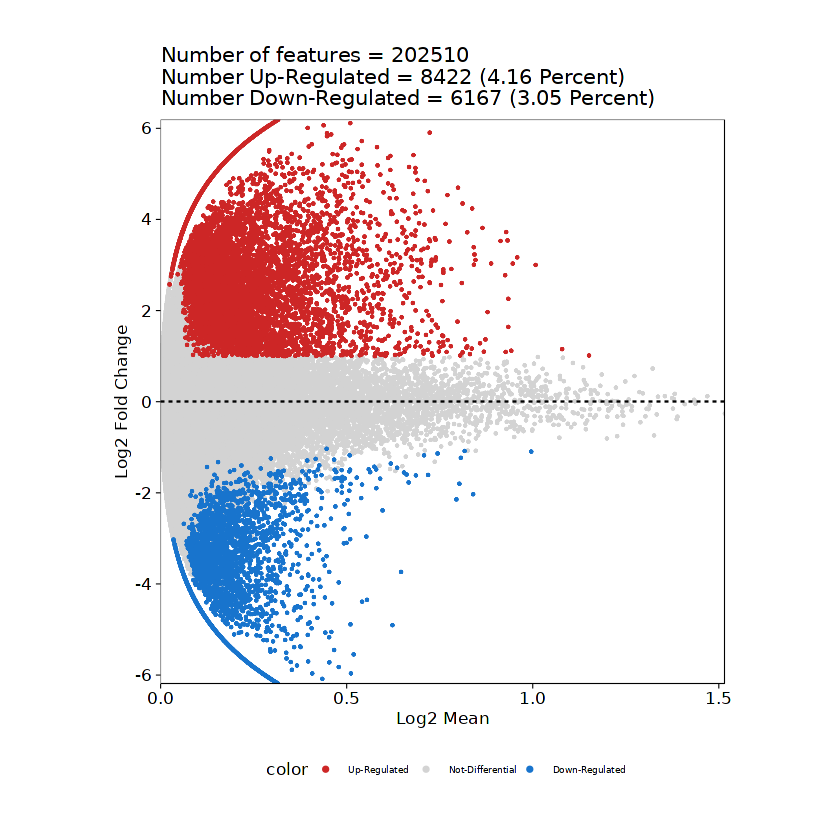

In [33]:
#绘制MA图
pma <- markerPlot(seMarker = markerTest, name = "Astro", cutOff = "FDR <= 0.1 & abs(Log2FC) >= 1", plotAs = "MA")
pma


Warning message:
“'markerPlot' is deprecated.
Use 'plotMarkers' instead.
See help("Deprecated")”
Warning message:
“Removed 94 rows containing missing values (geom_point_rast).”


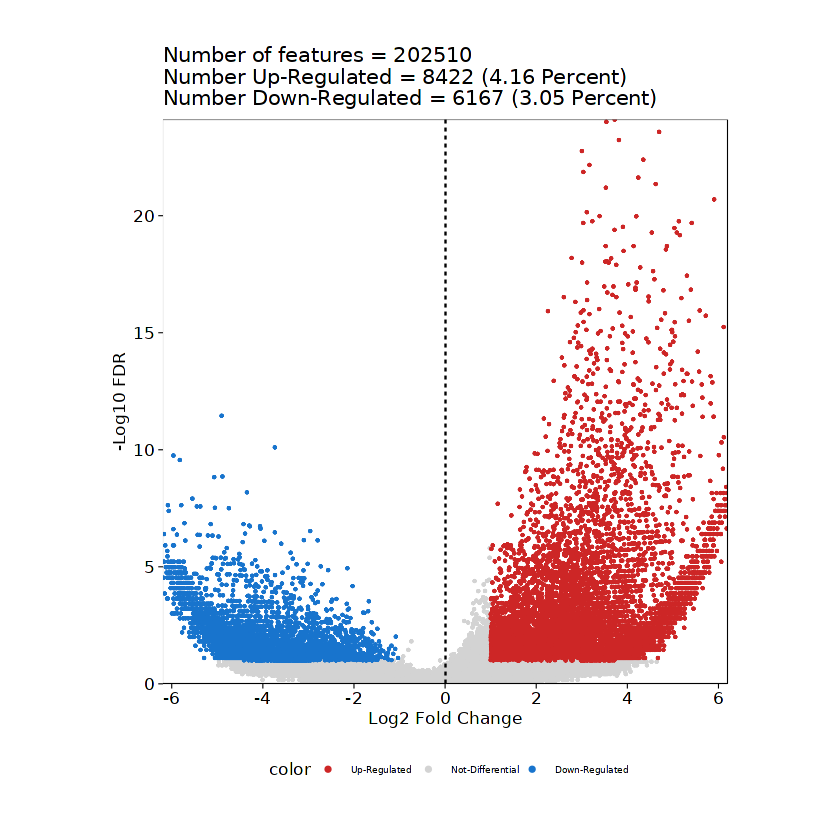

In [34]:
#绘制火山图
pv <- markerPlot(seMarker = markerTest, name = "Astro", cutOff = "FDR <= 0.1 & abs(Log2FC) >= 1", plotAs = "Volcano")
pv

# Motif-related Analysis

> Motif analysis helps understanding the transcription factors (TF) that cause chromatin opening and consequently peak detection since TFs bind to motifs. This will characterize the similarities and differences between peaks.

> Again, just loading the results from backup

## Annotate motifs using cisbp db

In [35]:
# proj <- addMotifAnnotations(ArchRProj = proj, motifSet = "cisbp", name = "Motif")

## Motif enrichment in differential peaks between Astro and CR

### Motifs in Up Peaks

In [36]:
motifsUp <- peakAnnoEnrichment(
    seMarker = markerTest,
    ArchRProj = proj,
    peakAnnotation = "Motif",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )
motifsUp

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-52ae6d0e5109-Date-2022-09-03_Time-10-04-55.log
If there is an issue, please report to github with logFile!

2022-09-03 10:05:03 : Computing Enrichments 1 of 1, 0.125 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-52ae6d0e5109-Date-2022-09-03_Time-10-04-55.log



class: SummarizedExperiment 
dim: 884 1 
metadata(0):
assays(10): mlog10Padj mlog10p ... CompareFrequency feature
rownames(884): Tcfap2a_1 Tcfap2b_2 ... Smad5_883 Smad9_884
rowData names(0):
colnames(1): Astro
colData names(0):

In [37]:
df <- data.frame(TF = rownames(motifsUp), mlog10Padj = assay(motifsUp)[,1])
df <- df[order(df$mlog10Padj, decreasing = TRUE),]
df$rank <- seq_len(nrow(df))

head(df)

,TF,mlog10Padj,rank
,<chr>,<dbl>,<int>
150,Sp2_150,167.4801,1
208,Zfa_208,163.7138,2
213,Zfy1_213,163.7138,3
800,Zfp148_800,144.6969,4
807,Maz_807,127.0508,5
806,Klf15_806,114.1405,6


Warning message:
“ggrepel: 17 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


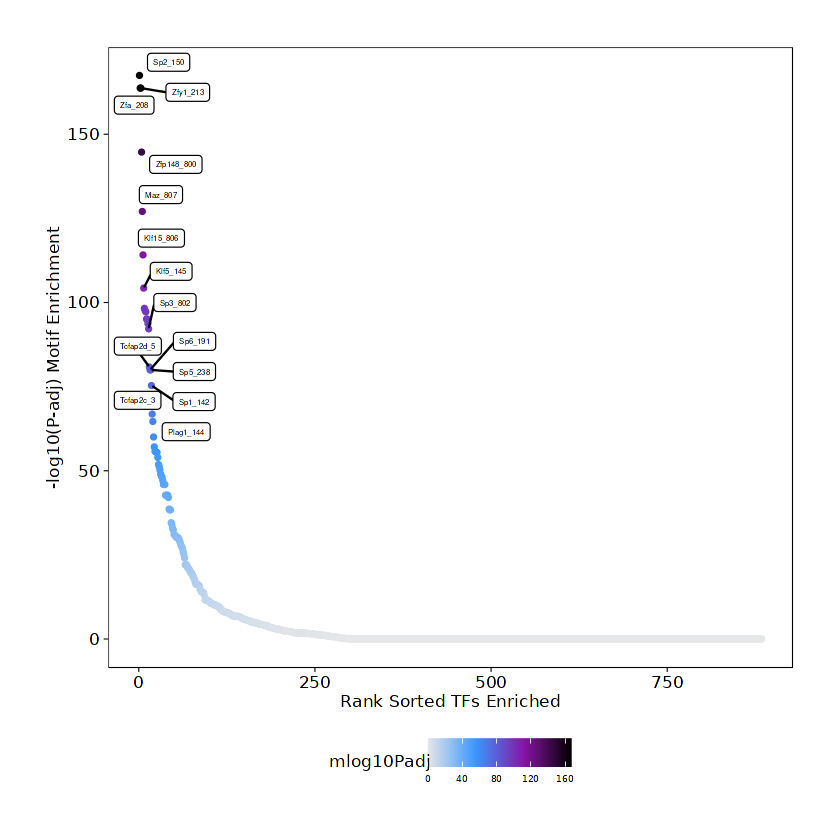

In [38]:
ggUp <- ggplot(df, aes(rank, mlog10Padj, color = mlog10Padj)) + 
  geom_point(size = 1) +
  ggrepel::geom_label_repel(
        data = df[rev(seq_len(30)), ], aes(x = rank, y = mlog10Padj, label = TF), 
        size = 1.5,
        nudge_x = 2,
        color = "black"
  ) + theme_ArchR() + 
  ylab("-log10(P-adj) Motif Enrichment") + 
  xlab("Rank Sorted TFs Enriched") +
  scale_color_gradientn(colors = paletteContinuous(set = "comet"))

ggUp

### Motifs in Down Peaks

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-52ae551de317-Date-2022-09-03_Time-10-05-06.log
If there is an issue, please report to github with logFile!

2022-09-03 10:05:14 : Computing Enrichments 1 of 1, 0.133 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-52ae551de317-Date-2022-09-03_Time-10-05-06.log



class: SummarizedExperiment 
dim: 884 1 
metadata(0):
assays(10): mlog10Padj mlog10p ... CompareFrequency feature
rownames(884): Tcfap2a_1 Tcfap2b_2 ... Smad5_883 Smad9_884
rowData names(0):
colnames(1): Astro
colData names(0):

Warning message:
“ggrepel: 25 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


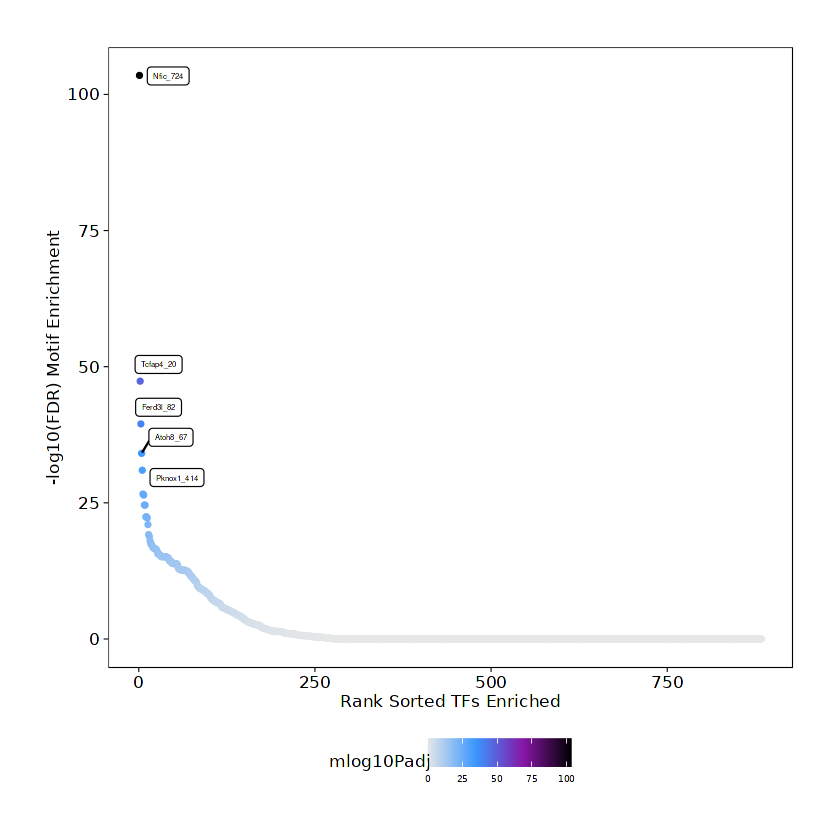

In [39]:
motifsDo <- peakAnnoEnrichment(
    seMarker = markerTest,
    ArchRProj = proj,
    peakAnnotation = "Motif",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  )
motifsDo

df <- data.frame(TF = rownames(motifsDo), mlog10Padj = assay(motifsDo)[,1])
df <- df[order(df$mlog10Padj, decreasing = TRUE),]
df$rank <- seq_len(nrow(df))



ggDo <- ggplot(df, aes(rank, mlog10Padj, color = mlog10Padj)) + 
  geom_point(size = 1) +
  ggrepel::geom_label_repel(
        data = df[rev(seq_len(30)), ], aes(x = rank, y = mlog10Padj, label = TF), 
        size = 1.5,
        nudge_x = 2,
        color = "black"
  ) + theme_ArchR() + 
  ylab("-log10(FDR) Motif Enrichment") +
  xlab("Rank Sorted TFs Enriched") +
  scale_color_gradientn(colors = paletteContinuous(set = "comet"))

ggDo

## Motifs in cell type specific peaks

In [138]:
enrichMotifs <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = proj,
    peakAnnotation = "Motif",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )

enrichMotifs

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-52ae41e06424-Date-2022-09-03_Time-13-51-24.log
If there is an issue, please report to github with logFile!

2022-09-03 13:51:33 : Computing Enrichments 1 of 6, 0.149 mins elapsed.

2022-09-03 13:51:33 : Computing Enrichments 2 of 6, 0.159 mins elapsed.

2022-09-03 13:51:35 : Computing Enrichments 3 of 6, 0.191 mins elapsed.

2022-09-03 13:51:36 : Computing Enrichments 4 of 6, 0.2 mins elapsed.

2022-09-03 13:51:36 : Computing Enrichments 5 of 6, 0.211 mins elapsed.

2022-09-03 13:51:37 : Computing Enrichments 6 of 6, 0.219 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-52ae41e06424-Date-2022-09-03_Time-13-51-24.log



class: SummarizedExperiment 
dim: 884 6 
metadata(0):
assays(10): mlog10Padj mlog10p ... CompareFrequency feature
rownames(884): Tcfap2a_1 Tcfap2b_2 ... Smad5_883 Smad9_884
rowData names(0):
colnames(6): Astro CR ... L6 IT Sst
colData names(0):

In [139]:
markersPeaks

class: SummarizedExperiment 
dim: 202510 6 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(202510): 1 2 ... 202509 202510
rowData names(4): seqnames idx start end
colnames(6): Astro CR ... L6 IT Sst
colData names(0):

In [140]:
heatmapEM <- plotEnrichHeatmap(enrichMotifs, cutOff = 10, rastr = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-52ae6835165f-Date-2022-09-03_Time-14-07-05.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..



In [141]:
heatmapEM

ERROR while rich displaying an object: Error in grid.Call.graphics(C_downvppath, name$path, name$name, strict): Viewport 'Norm. Enrichment -log10(P-adj) [0-Max]_heatmap_body_1_1' was not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = er

> There is something wrong with the heatmapEM object and the heatmap cannot be generated

In [ ]:
ComplexHeatmap::draw(heatmapEM, heatmap_legend_side = "bot", annotation_legend_side = "bot")

## Identify motif deviation

> Deviation: difference between expected and real chromatin accessibility

### Sample background peaks

In [41]:
# if("Motif" %ni% names(proj@peakAnnotation)){
#     proj <- addMotifAnnotations(ArchRProj = proj, motifSet = "cisbp", name = "Motif")
# }

# proj <- addBgdPeaks(proj)

### Add deviation matrix

In [42]:
# proj <- addDeviationsMatrix(
#   ArchRProj = proj, 
#   peakAnnotation = "Motif",
#   force = TRUE
# )

DataFrame with 6 rows and 6 columns
     seqnames     idx        name combinedVars combinedMeans      rank
        <Rle> <array>     <array>    <numeric>     <numeric> <integer>
f843        z     843 Smarcc1_843      42.0218     -0.447864         1
f104        z     104     Fos_104      41.3434     -0.454320         2
f108        z     108   Bach1_108      29.7753     -0.421804         3
f98         z      98     Fosb_98      25.4724     -0.402111         4
f119        z     119   Bach2_119      23.7209     -0.297896         5
f135        z     135    Jund_135      19.1639     -0.295178         6


Warning message:
“ggrepel: 19 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


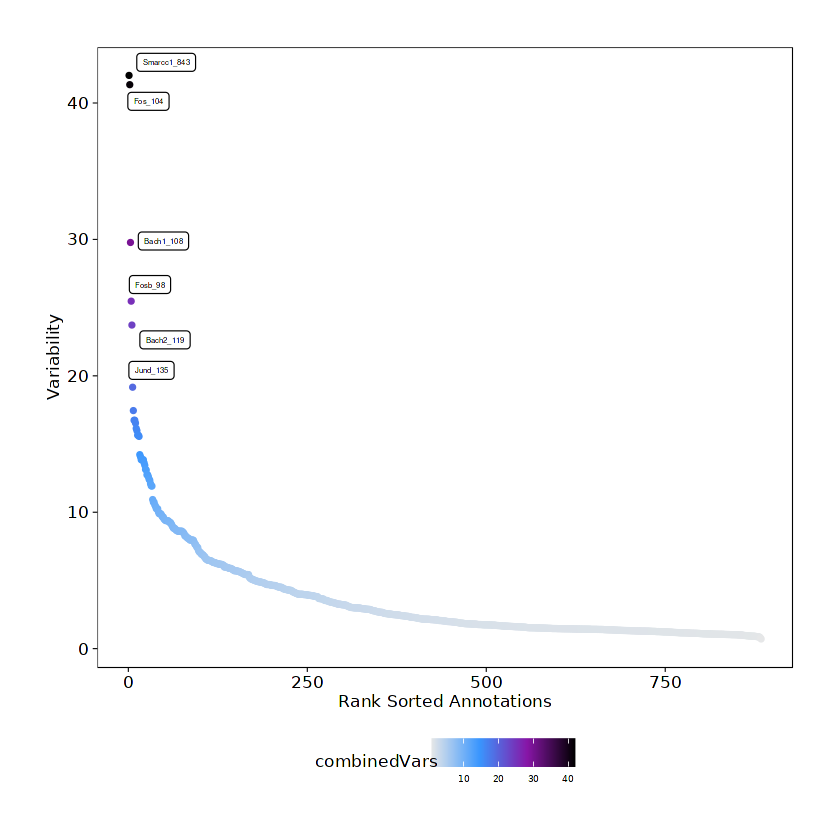

In [43]:
plotVarDev <- getVarDeviations(proj, name = "MotifMatrix", plot = TRUE)
plotVarDev

### Get motifs for downstream analysis

> Here I chose 3 marker genes of Astro and CR cells. TRP73 and EOMES are CR marker genes. Sox9 is an Astro marker gene.

In [44]:
motifs <- c("Sox9", "TRP73","EOMES")
markerMotifs <- getFeatures(proj, select = paste(motifs, collapse="|"), useMatrix = "MotifMatrix")
markerMotifs

# Only want z score
markerMotifs <- grep("z:", markerMotifs, value = TRUE)

markerMotifs

[1] "z:Eomes_768"          "z:Sox9_725"           "z:Trp73_691"         
[4] "deviations:Eomes_768" "deviations:Sox9_725"  "deviations:Trp73_691"

[1] "z:Eomes_768" "z:Sox9_725"  "z:Trp73_691"

### ChromVar deviation for the motifs in each cluster

Getting ImputeWeights

Getting Matrix Values...

2022-09-03 10:05:48 : 

1 


ArchR logging to : ArchRLogs/ArchR-imputeMatrix-52ae53faeebc-Date-2022-09-03_Time-10-05-50.log
If there is an issue, please report to github with logFile!

Using weights on disk

Using weights on disk

1 
2 
3 


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Picking joint bandwidth of 0.179

Picking joint bandwidth of 0.119

Picking joint bandwidth of 0.0668



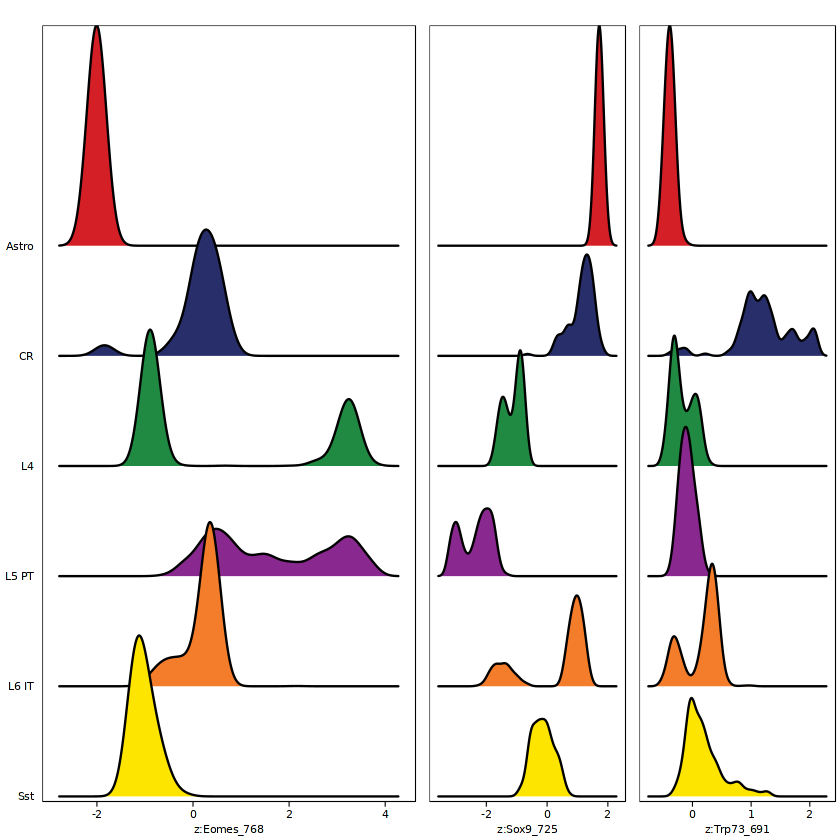

In [45]:
p <- plotGroups(ArchRProj = proj, 
  groupBy = "celltype", 
  colorBy = "MotifMatrix", 
  name = markerMotifs,
  imputeWeights = getImputeWeights(proj)
)
#使用cowplot将不同的moitfs的分布组合在一张图中
p2 <- lapply(seq_along(p), function(x){
  if(x != 1){
    p[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})
do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(2, rep(1, length(p2) - 1))),p2))

> Sox9 has very different deviation in the astrocyte cluster

### Visualize the z-scores of the motifs of interest

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-52ae3eaa8c72-Date-2022-09-03_Time-10-05-55.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = MotifMatrix

Getting Matrix Values...

2022-09-03 10:05:55 : 

1 


Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 
2 
3 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-52ae3eaa8c72-Date-2022-09-03_Time-10-05-55.log

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”


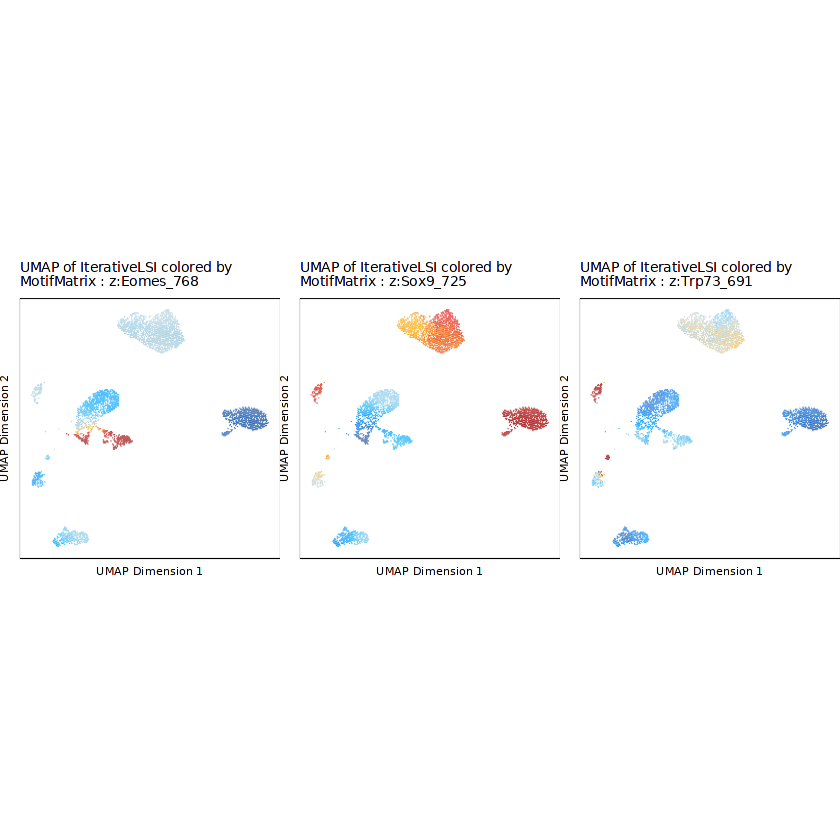

In [46]:
p <- plotEmbedding(
    ArchRProj = proj, 
    colorBy = "MotifMatrix", 
    name = sort(markerMotifs), 
    embedding = "UMAP",
    imputeWeights = getImputeWeights(proj)
)
#可以使用cowplot将motif UMAP放在一张图上展示
p2 <- lapply(p, function(x){
    x + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6.5) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
    theme(
        axis.text.x=element_blank(), 
        axis.ticks.x=element_blank(), 
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank()
    )
})
do.call(cowplot::plot_grid, c(list(ncol = 3),p2))

### Visualize gene scores of the motifs of interest

In [47]:
markerRNA <- getFeatures(proj, select = paste(motifs, collapse="|"), useMatrix = "GeneScoreMatrix")
markerRNA

[1] "Sox9"  "Trp73" "Eomes"

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-52ae1ab88a9b-Date-2022-09-03_Time-10-06-03.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2022-09-03 10:06:03 : 

1 


Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 
2 
3 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-52ae1ab88a9b-Date-2022-09-03_Time-10-06-03.log

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”


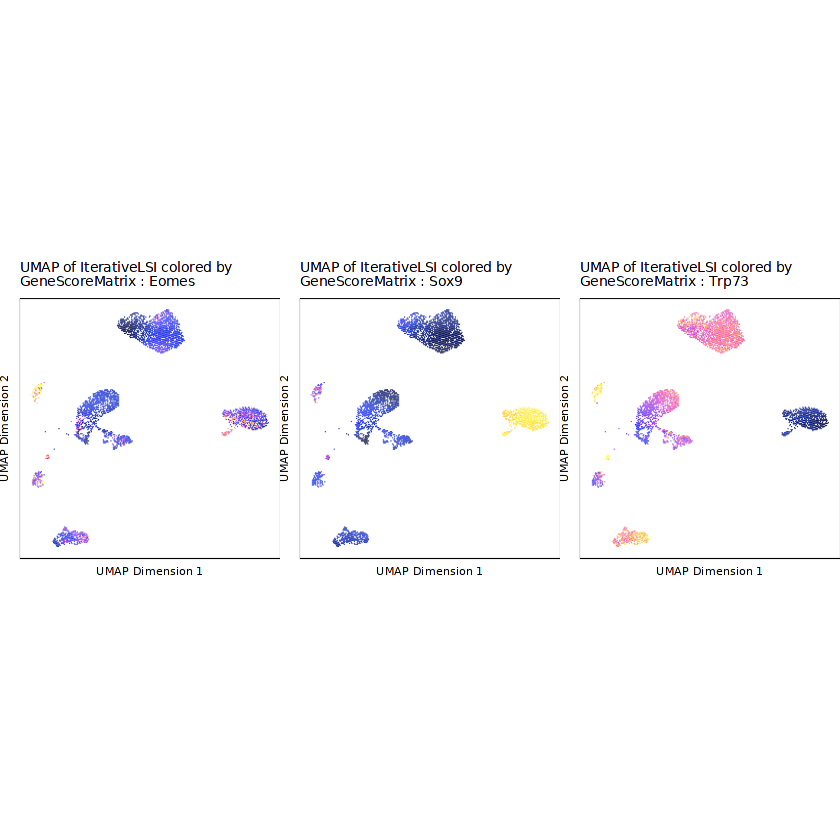

In [48]:
# 获取GeneScoreMatrix
p <- plotEmbedding(
    ArchRProj = proj, 
    colorBy = "GeneScoreMatrix", 
    name = sort(markerRNA), 
    embedding = "UMAP",
    imputeWeights = getImputeWeights(proj)
)
# 同时处理的多个图
p2 <- lapply(p, function(x){
    x + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6.5) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
    theme(
        axis.text.x=element_blank(), 
        axis.ticks.x=element_blank(), 
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank()
    )
})
#可以使用cowplot将gene activity score的图放在一张图上展示拼图
do.call(cowplot::plot_grid, c(list(ncol = 3),p2))

> The gene expression level of the 3 genes are not so similar, unlike deviation scores.

### Visualize with gene expression data from scRNA seq for the motifs of interest

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-52ae4be8dc80-Date-2022-09-03_Time-10-06-10.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneIntegrationMatrix

Getting Matrix Values...

2022-09-03 10:06:10 : 

1 


Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 
2 
3 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-52ae4be8dc80-Date-2022-09-03_Time-10-06-10.log

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”


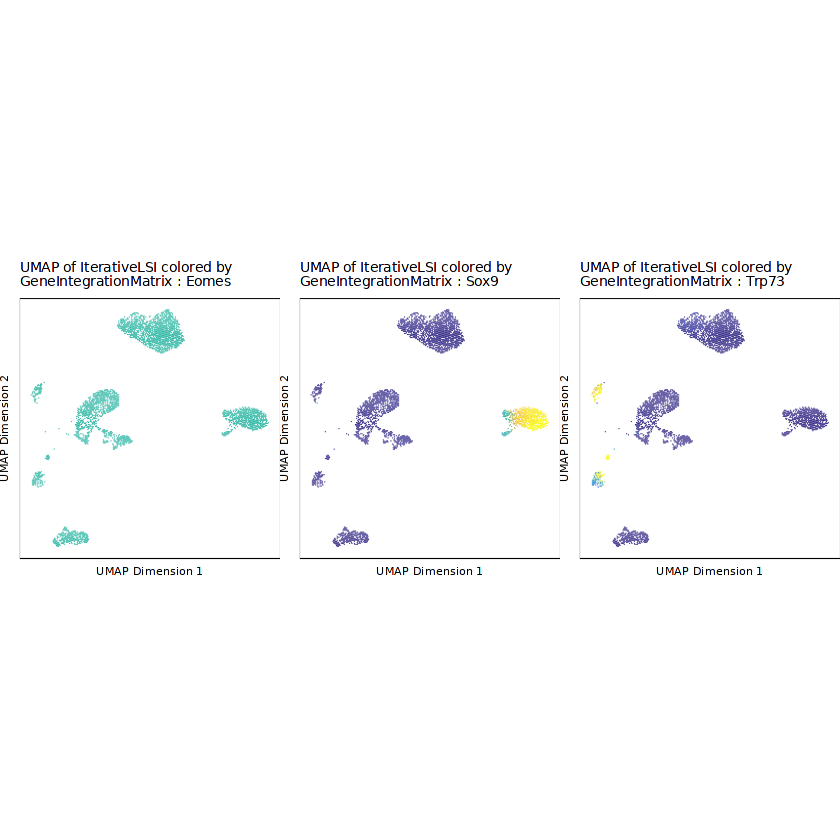

In [49]:
markerRNA <- getFeatures(proj, select = paste(motifs, collapse="|"), useMatrix = "GeneIntegrationMatrix")
# markerRNA <- markerRNA[markerRNA %ni% c("SREBF1","CEBPA-DT")] # Removes unwanted name overlap
p <- plotEmbedding(
    ArchRProj = proj, 
    colorBy = "GeneIntegrationMatrix", 
    name = sort(markerRNA), 
    embedding = "UMAP",
    continuousSet = "blueYellow",
    imputeWeights = getImputeWeights(proj)
)
p2 <- lapply(p, function(x){
    x + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6.5) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
    theme(
        axis.text.x=element_blank(), 
        axis.ticks.x=element_blank(), 
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank()
    )
})
do.call(cowplot::plot_grid, c(list(ncol = 3),p2))

## Footprint analysis

> Footprint: parts of the genome that are actively bound by TFs when Tn5 insertion happens will not be inserted; hence leaving a "footprint" in the insertion count plot.
  
> Kinda like stepping in the snow.  
  
> This allows us to find exact positions of TF binding.
  
> Getting exact binding sites also compensates for Tn5 insertion bias; done with magical ArchR algorithms.

### Get motif positions

In [50]:
motifPositions <- getPositions(proj)
motifPositions

GRangesList object of length 884:
$Tcfap2a_1
GRanges object with 17470 ranges and 1 metadata column:
          seqnames              ranges strand |     score
             <Rle>           <IRanges>  <Rle> | <numeric>
      [1]     chr1     4571942-4571951      - |   7.04113
      [2]     chr1     4857513-4857522      + |   6.97203
      [3]     chr1     5022937-5022946      - |   7.32229
      [4]     chr1     5249580-5249589      + |   7.31527
      [5]     chr1     6214851-6214860      + |   6.89795
      ...      ...                 ...    ... .       ...
  [17466]     chrX 166479742-166479751      - |   7.52746
  [17467]     chrX 167105992-167106001      - |   7.03835
  [17468]     chrX 167209093-167209102      - |   7.22216
  [17469]     chrX 168673410-168673419      - |   7.41541
  [17470]     chrX 169611665-169611674      + |   6.89415
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

...
<883 more elements>

In [51]:
motifs <- c("Sox9", "Trp73","Eomes")
markerMotifs <- unlist(lapply(motifs, function(x) grep(x, names(motifPositions), value = TRUE)))

markerMotifs

[1] "Sox9_725"  "Trp73_691" "Eomes_768"

### Create pesudo bulk (already did)

> This is a necessary step as footprint analysis require high sequencing depth

In [52]:
#proj <- addGroupCoverages(ArchRProj = proj, groupBy = "celltype")

### Compute footprints for selected motifs

In [53]:
seFoot <- getFootprints(
  ArchRProj = proj, 
  positions = motifPositions[markerMotifs], 
  groupBy = "celltype"
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-52ae2dd202f0-Date-2022-09-03_Time-10-06-26.log
If there is an issue, please report to github with logFile!

2022-09-03 10:06:27 : Computing Kmer Bias Table, 0.002 mins elapsed.

2022-09-03 10:06:30 : Finished Computing Kmer Tables, 0.063 mins elapsed.

2022-09-03 10:06:30 : Computing Footprints, 0.065 mins elapsed.

2022-09-03 10:06:41 : Computing Footprints Bias, 0.249 mins elapsed.

2022-09-03 10:06:47 : Summarizing Footprints, 0.345 mins elapsed.



### Remove Tn5 insertion bias by substraction or division

In [54]:
plotFootprints(
  seFoot = seFoot,
  ArchRProj = proj, 
  normMethod = "Subtract",
  plotName = "Footprints-Subtract-Bias",
  addDOC = FALSE,
  smoothWindow = 5
)

ArchR logging to : ArchRLogs/ArchR-plotFootprints-52ae597a2fb3-Date-2022-09-03_Time-10-06-49.log
If there is an issue, please report to github with logFile!

2022-09-03 10:06:49 : Plotting Footprint : Sox9_725 (1 of 3), 0.001 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2022-09-03 10:06:50 : Plotting Footprint : Trp73_691 (2 of 3), 0.018 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2022-09-03 10:06:51 : Plotting Footprint : Eomes_768 (3 of 3), 0.038 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

ArchR logging successful to : ArchRLogs/ArchR-plotFootprints-52ae597a2fb3-Date-2022-09-03_Time-10-06-49.log



In [55]:
plotFootprints(
  seFoot = seFoot,
  ArchRProj = proj, 
  normMethod = "Divide",
  plotName = "Footprints-Divide-Bias",
  addDOC = FALSE,
  smoothWindow = 5
)

ArchR logging to : ArchRLogs/ArchR-plotFootprints-52ae5bef3225-Date-2022-09-03_Time-10-06-54.log
If there is an issue, please report to github with logFile!

2022-09-03 10:06:54 : Plotting Footprint : Sox9_725 (1 of 3), 0.001 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Divide

2022-09-03 10:06:55 : Plotting Footprint : Trp73_691 (2 of 3), 0.019 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Divide

2022-09-03 10:06:56 : Plotting Footprint : Eomes_768 (3 of 3), 0.038 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Divide

ArchR logging successful to : ArchRLogs/ArchR-plotFootprints-52ae5bef3225-Date-2022-09-03_Time-10-06-54.log



### Foot print analysis for other features, like TSS

In [56]:
#proj <- addGroupCoverages(ArchRProj = proj, groupBy = "celltype")

In [57]:
seTSS <- getFootprints(
  ArchRProj = proj, 
  positions = GRangesList(TSS = getTSS(proj)), 
  groupBy = "celltype",
  flank = 2000
)
#plotFootprints()对每个细胞分组绘制TSS插入谱。
plotFootprints(
  seFoot = seTSS,
  ArchRProj = proj, 
  normMethod = "None",
  plotName = "TSS-No-Normalization",
  addDOC = FALSE,
  flank = 2000,
  flankNorm = 100
)   

ArchR logging to : ArchRLogs/ArchR-getFootprints-52ae4841783-Date-2022-09-03_Time-10-07-04.log
If there is an issue, please report to github with logFile!

2022-09-03 10:07:04 : Computing Kmer Bias Table, 0.002 mins elapsed.

2022-09-03 10:07:25 : Finished Computing Kmer Tables, 0.337 mins elapsed.

2022-09-03 10:07:25 : Computing Footprints, 0.339 mins elapsed.

2022-09-03 10:07:38 : Computing Footprints Bias, 0.561 mins elapsed.

2022-09-03 10:07:47 : Summarizing Footprints, 0.707 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-plotFootprints-52ae1974b3a0-Date-2022-09-03_Time-10-07-48.log
If there is an issue, please report to github with logFile!

2022-09-03 10:07:48 : Plotting Footprint : TSS (1 of 1), 0.001 mins elapsed.

Normalizing by flanking regions

NormMethod = None

ArchR logging successful to : ArchRLogs/ArchR-plotFootprints-52ae1974b3a0-Date-2022-09-03_Time-10-07-48.log



# Integrated Analysis

## CoAccessbility

> Co-accessible: between two peaks, when one is open, the other is usually open, too
  
> Co-accessible peaks are usually consistent within a cell type

### Compute CoA matrix

In [66]:
proj <- addCoAccessibility(
    ArchRProj = proj,
    reducedDims = "IterativeLSI"
)   

ArchR logging to : ArchRLogs/ArchR-addCoAccessibility-52ae751b6c9b-Date-2022-09-03_Time-11-44-51.log
If there is an issue, please report to github with logFile!

2022-09-03 11:44:51 : Computing KNN, 0.001 mins elapsed.

2022-09-03 11:44:51 : Identifying Non-Overlapping KNN pairs, 0.002 mins elapsed.

2022-09-03 11:44:54 : Identified 465 Groupings!, 0.039 mins elapsed.

2022-09-03 11:44:55 : Computing Co-Accessibility chr1 (1 of 20), 0.059 mins elapsed.

2022-09-03 11:45:01 : Computing Co-Accessibility chr2 (2 of 20), 0.166 mins elapsed.

2022-09-03 11:45:09 : Computing Co-Accessibility chr3 (3 of 20), 0.288 mins elapsed.

2022-09-03 11:45:15 : Computing Co-Accessibility chr4 (4 of 20), 0.391 mins elapsed.

2022-09-03 11:45:22 : Computing Co-Accessibility chr5 (5 of 20), 0.518 mins elapsed.

2022-09-03 11:45:29 : Computing Co-Accessibility chr6 (6 of 20), 0.632 mins elapsed.

2022-09-03 11:45:35 : Computing Co-Accessibility chr7 (7 of 20), 0.723 mins elapsed.

2022-09-03 11:45:43 : Comp

### Get CoA matrix

In [67]:
cA <- getCoAccessibility(
    ArchRProj = proj,
    corCutOff = 0.5,
    resolution = 1,
    returnLoops = FALSE
)
cA
# 该DataFrame对象包含几个重要的信息。queryHits和subjectHits列记录的是两个存在相关性的peak的索引。correlation则是两个peak之间的开放状态相关的数值。

DataFrame with 541170 rows and 11 columns
       queryHits subjectHits seqnames correlation Variability1 Variability2
       <integer>   <integer>    <Rle>   <numeric>    <numeric>    <numeric>
1              2           6     chr1    0.574660   0.00319199  0.000203816
2              2           7     chr1    0.536549   0.00319199  0.001049322
3              3           5     chr1    0.524177   0.00371753  0.002483011
4              4           5     chr1    0.500267   0.00279315  0.002483011
5              5           3     chr1    0.524177   0.00248301  0.003717532
...          ...         ...      ...         ...          ...          ...
541166    202506      202510     chrX    0.920534   0.01392146   0.02011007
541167    202507      202506     chrX    0.581341   0.00020613   0.01392146
541168    202507      202510     chrX    0.576452   0.00020613   0.02011007
541169    202510      202506     chrX    0.920534   0.02011007   0.01392146
541170    202510      202507     chrX    0.576

In [68]:
metadata(cA)[[1]]
# Can be indexed with queryHits and subjectHits

GRanges object with 202510 ranges and 0 metadata columns:
        seqnames              ranges strand
           <Rle>           <IRanges>  <Rle>
  L6 IT     chr1     3012490-3012990      *
    Sst     chr1     3094765-3095265      *
  L5 PT     chr1     3113546-3114046      *
  L6 IT     chr1     3119400-3119900      *
  L5 PT     chr1     3120224-3120724      *
    ...      ...                 ...    ...
  Astro     chrX 169838269-169838769      *
  Astro     chrX 169844120-169844620      *
     CR     chrX 169881880-169882380      *
  L6 IT     chrX 169923357-169923857      *
  Astro     chrX 169925521-169926021      *
  -------
  seqinfo: 20 sequences from an unspecified genome; no seqlengths

In [69]:
cA <- getCoAccessibility(
    ArchRProj = proj,
    corCutOff = 0.5,
    resolution = 1,
    returnLoops = TRUE
)
cA[[1]]

GRanges object with 270585 ranges and 9 metadata columns:
           seqnames              ranges strand | correlation Variability1
              <Rle>           <IRanges>  <Rle> |   <numeric>    <numeric>
       [1]     chr1     3095015-3134946      * |    0.574660   0.00319199
       [2]     chr1     3095015-3167417      * |    0.536549   0.00319199
       [3]     chr1     3113796-3120474      * |    0.524177   0.00371753
       [4]     chr1     3119650-3120474      * |    0.500267   0.00279315
       [5]     chr1     3120474-3167417      * |    0.505346   0.00248301
       ...      ...                 ...    ... .         ...          ...
  [270581]     chrX 168603838-168649523      * |    0.732431  0.000867641
  [270582]     chrX 169056359-169104080      * |    0.546031  0.002951009
  [270583]     chrX 169838519-169844370      * |    0.581341  0.013921464
  [270584]     chrX 169838519-169925771      * |    0.920534  0.013921464
  [270585]     chrX 169844370-169925771      * |    0.

> 1000 is lower resolution and reduces the number of rows

In [70]:
cA <- getCoAccessibility(
    ArchRProj = proj,
    corCutOff = 0.5,
    resolution = 1000,
    returnLoops = TRUE
)

cA[[1]]


GRanges object with 253691 ranges and 9 metadata columns:
           seqnames              ranges strand | correlation Variability1
              <Rle>           <IRanges>  <Rle> |   <numeric>    <numeric>
       [1]     chr1     3095500-3134500      * |    0.574660   0.00319199
       [2]     chr1     3095500-3167500      * |    0.536549   0.00319199
       [3]     chr1     3113500-3120500      * |    0.524177   0.00371753
       [4]     chr1     3119500-3120500      * |    0.500267   0.00279315
       [5]     chr1     3120500-3167500      * |    0.505346   0.00248301
       ...      ...                 ...    ... .         ...          ...
  [253687]     chrX 168603500-168649500      * |    0.732431  0.000867641
  [253688]     chrX 169056500-169104500      * |    0.546031  0.002951009
  [253689]     chrX 169838500-169844500      * |    0.581341  0.013921464
  [253690]     chrX 169838500-169925500      * |    0.920534  0.013921464
  [253691]     chrX 169844500-169925500      * |    0.

In [82]:
markerGenes  <- c(
    "Sox9", #Astro
    "GFAP",
    "SLC1A2",
    "ACSBG1",
    "S100B",
    "SLC1A3",
    "GJA1",
    "AQP4",
    "LCN2",
    "S1PR1",
    "APOE",
    "ALDOC",
    "RLBP1",
    "TEAD1",
    "WNT3",
    "SLC25A46",
    "Eomes", #CR
    "CNR1",
    "CALB2",
    "EBF3"
)

ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-52ae15991b9b-Date-2022-09-03_Time-12-05-05.log
If there is an issue, please report to github with logFile!

2022-09-03 12:05:05 : Validating Region, 0.001 mins elapsed.



GRanges object with 20 ranges and 2 metadata columns:
       seqnames              ranges strand |     gene_id      symbol
          <Rle>           <IRanges>  <Rle> | <character> <character>
   [1]    chr11 112782210-112787757      + |       20682        Sox9
   [2]    chr11 102887336-102897200      - |       14580        Gfap
   [3]     chr2 102658683-102790784      + |       20511      Slc1a2
   [4]     chr9   54604997-54661885      - |       94180      Acsbg1
   [5]    chr10   76253836-76261319      + |       20203       S100b
   ...      ...                 ...    ... .         ...         ...
  [16]    chr18   31580168-31610528      - |       67453    Slc25a46
  [17]     chr9 118478189-118486132      + |       13813       Eomes
  [18]     chr4   33924632-33948831      + |       12801        Cnr1
  [19]     chr8 110137504-110168206      - |       12308       Calb2
  [20]     chr7 137193671-137314445      - |       13593        Ebf3
  -------
  seqinfo: 21 sequences from mm10 genom

2022-09-03 12:05:05 : Adding Bulk Tracks (1 of 20), 0.003 mins elapsed.

Getting Region From Arrow Files 1 of 1

2022-09-03 12:05:06 : Adding Feature Tracks (1 of 20), 0.022 mins elapsed.

2022-09-03 12:05:06 : Adding Loop Tracks (1 of 20), 0.023 mins elapsed.

2022-09-03 12:05:09 : Adding Gene Tracks (1 of 20), 0.066 mins elapsed.

2022-09-03 12:05:09 : Plotting, 0.069 mins elapsed.

2022-09-03 12:05:10 : Adding Bulk Tracks (2 of 20), 0.092 mins elapsed.

Getting Region From Arrow Files 1 of 1

2022-09-03 12:05:12 : Adding Feature Tracks (2 of 20), 0.111 mins elapsed.

2022-09-03 12:05:12 : Adding Loop Tracks (2 of 20), 0.112 mins elapsed.

2022-09-03 12:05:13 : Adding Gene Tracks (2 of 20), 0.13 mins elapsed.

2022-09-03 12:05:13 : Plotting, 0.132 mins elapsed.

2022-09-03 12:05:14 : Adding Bulk Tracks (3 of 20), 0.158 mins elapsed.

Getting Region From Arrow Files 1 of 1

2022-09-03 12:05:16 : Adding Feature Tracks (3 of 20), 0.179 mins elapsed.

2022-09-03 12:05:16 : Adding Loop Tr

$Sox9
TableGrob (68 x 12) "layout": 91 grobs
    z         cells        name                                          grob
1   0 ( 1-32, 1-10)  background             rect[plot.background..rect.24491]
2   1 ( 7- 7, 5- 5)   panel-1-1                    gTree[panel-1.gTree.24261]
3   1 (11-11, 5- 5)   panel-1-2                    gTree[panel-2.gTree.24273]
4   1 (15-15, 5- 5)   panel-1-3                    gTree[panel-3.gTree.24285]
5   1 (19-19, 5- 5)   panel-1-4                    gTree[panel-4.gTree.24297]
6   1 (23-23, 5- 5)   panel-1-5                    gTree[panel-5.gTree.24309]
7   1 (27-27, 5- 5)   panel-1-6                    gTree[panel-6.gTree.24321]
8   3 (26-26, 5- 5)  axis-t-1-6                                zeroGrob[NULL]
9   3 (22-22, 5- 5)  axis-t-1-5                                zeroGrob[NULL]
10  3 (18-18, 5- 5)  axis-t-1-4                                zeroGrob[NULL]
11  3 (14-14, 5- 5)  axis-t-1-3                                zeroGrob[NULL]
12  3 (10-10, 5- 5)

In [85]:
plots <- plotBrowserTrack(
    ArchRProj = proj, 
    groupBy = "celltype", 
    geneSymbol = markerGenes, 
    upstream = 100000,
    downstream = 100000,
    loops = getCoAccessibility(proj,resolution=1)
)


ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-52ae25553907-Date-2022-09-03_Time-12-08-51.log
If there is an issue, please report to github with logFile!

2022-09-03 12:08:51 : Validating Region, 0.001 mins elapsed.



GRanges object with 20 ranges and 2 metadata columns:
       seqnames              ranges strand |     gene_id      symbol
          <Rle>           <IRanges>  <Rle> | <character> <character>
   [1]    chr11 112782210-112787757      + |       20682        Sox9
   [2]    chr11 102887336-102897200      - |       14580        Gfap
   [3]     chr2 102658683-102790784      + |       20511      Slc1a2
   [4]     chr9   54604997-54661885      - |       94180      Acsbg1
   [5]    chr10   76253836-76261319      + |       20203       S100b
   ...      ...                 ...    ... .         ...         ...
  [16]    chr18   31580168-31610528      - |       67453    Slc25a46
  [17]     chr9 118478189-118486132      + |       13813       Eomes
  [18]     chr4   33924632-33948831      + |       12801        Cnr1
  [19]     chr8 110137504-110168206      - |       12308       Calb2
  [20]     chr7 137193671-137314445      - |       13593        Ebf3
  -------
  seqinfo: 21 sequences from mm10 genom

2022-09-03 12:08:51 : Adding Bulk Tracks (1 of 20), 0.003 mins elapsed.

Getting Region From Arrow Files 1 of 1

2022-09-03 12:08:52 : Adding Feature Tracks (1 of 20), 0.022 mins elapsed.

2022-09-03 12:08:52 : Adding Loop Tracks (1 of 20), 0.023 mins elapsed.

2022-09-03 12:08:56 : Adding Gene Tracks (1 of 20), 0.088 mins elapsed.

2022-09-03 12:08:56 : Plotting, 0.091 mins elapsed.

2022-09-03 12:08:58 : Adding Bulk Tracks (2 of 20), 0.122 mins elapsed.

Getting Region From Arrow Files 1 of 1

2022-09-03 12:08:59 : Adding Feature Tracks (2 of 20), 0.14 mins elapsed.

2022-09-03 12:08:59 : Adding Loop Tracks (2 of 20), 0.141 mins elapsed.

2022-09-03 12:09:01 : Adding Gene Tracks (2 of 20), 0.169 mins elapsed.

2022-09-03 12:09:01 : Plotting, 0.172 mins elapsed.

2022-09-03 12:09:03 : Adding Bulk Tracks (3 of 20), 0.212 mins elapsed.

Getting Region From Arrow Files 1 of 1

2022-09-03 12:09:05 : Adding Feature Tracks (3 of 20), 0.233 mins elapsed.

2022-09-03 12:09:05 : Adding Loop Tr

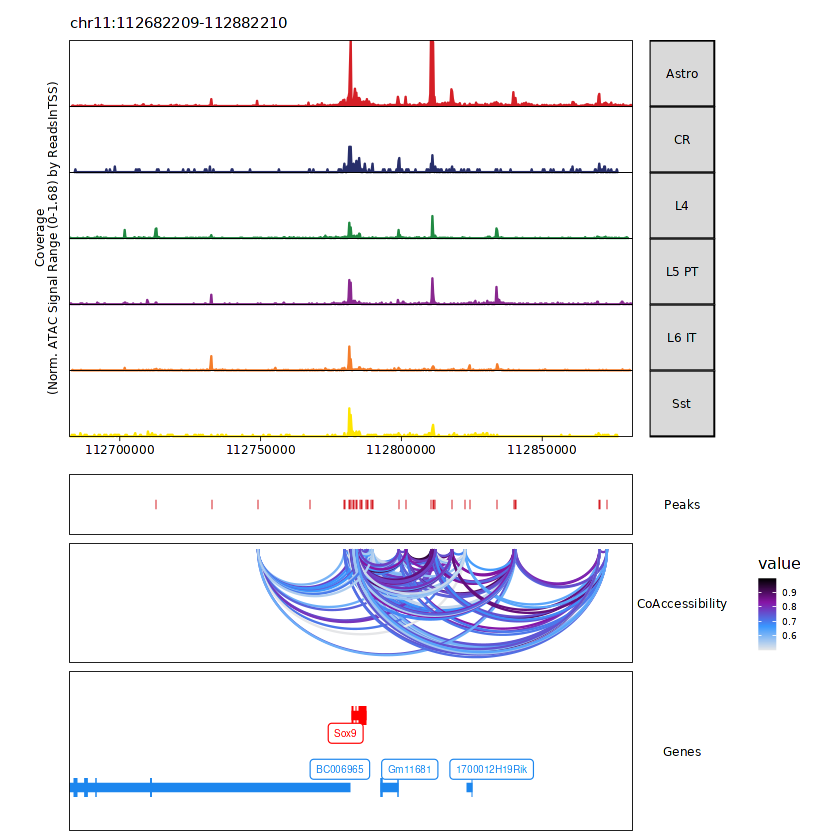

In [89]:
#最后用grid.draw函数绘制结果，通过$选择特定的标记基因。
grid::grid.newpage()
grid::grid.draw(plots$Sox9)

## Positive regulators TF Identification

> These TFs cause chromain opening. They can be found with either gene expression data from scRNA seq because TF binding causes gene expression or with gene activity score from scATAC alone. Correlation is computed using one of these two matrices with TF motif deviation.

### Identify TF binding motifs with deviation

In [90]:
# Average motif deviation based on cell type
seGroupMotif <- getGroupSE(ArchRProj = proj, useMatrix = "MotifMatrix", groupBy = "celltype")
seGroupMotif

ArchR logging to : ArchRLogs/ArchR-getGroupSE-52ae5b4aea62-Date-2022-09-03_Time-12-21-11.log
If there is an issue, please report to github with logFile!

Getting Group Matrix

2022-09-03 12:21:16 : Successfully Created Group Matrix, 0.076 mins elapsed.

Normalizing by number of Cells

ArchR logging successful to : ArchRLogs/ArchR-getGroupSE-52ae5b4aea62-Date-2022-09-03_Time-12-21-11.log



class: SummarizedExperiment 
dim: 1768 6 
metadata(0):
assays(1): MotifMatrix
rownames(1768): f1 f2 ... f1767 f1768
rowData names(3): seqnames idx name
colnames(6): Astro CR ... L6 IT Sst
colData names(18): TSSEnrichment ReadsInTSS ... FRIP nCells

In [91]:
seZ <- seGroupMotif[rowData(seGroupMotif)$seqnames=="z",] # filter z scores only

In [92]:
# Rank motifs based on z scores in different cell types
rowData(seZ)$maxDelta <- lapply(seq_len(ncol(seZ)), function(x){
  rowMaxs(assay(seZ) - assay(seZ)[,x])
}) %>% Reduce("cbind", .) %>% rowMaxs

seZ

class: SummarizedExperiment 
dim: 884 6 
metadata(0):
assays(1): MotifMatrix
rownames(884): f885 f886 ... f1767 f1768
rowData names(4): seqnames idx name maxDelta
colnames(6): Astro CR ... L6 IT Sst
colData names(18): TSSEnrichment ReadsInTSS ... FRIP nCells

### Compute correlation between motif and gene activity

> Gene activity can be from either gene score matrix or gene integration matrix

In [93]:
corGSM_MM <- correlateMatrices(
    ArchRProj = proj,
    useMatrix1 = "GeneScoreMatrix",
    useMatrix2 = "MotifMatrix",
    reducedDims = "IterativeLSI"
)
corGSM_MM
# 该函数返回一个DataFrame对象，记录着GeneScoreMatrix和MotifMatrix，以及它们在低重叠细胞聚类中的相关性。

ArchR logging to : ArchRLogs/ArchR-correlateMatrices-52ae5d4478ac-Date-2022-09-03_Time-12-33-19.log
If there is an issue, please report to github with logFile!

When accessing features from a matrix of class Sparse.Assays.Matrix it requires 1 seqname!
Continuing with first seqname 'z'!
If confused, try getFeatures(ArchRProj, 'MotifMatrix') to list out available seqnames for input!

2022-09-03 12:33:21 : Testing 791 Mappings!, 0.031 mins elapsed.

2022-09-03 12:33:21 : Computing KNN, 0.031 mins elapsed.

2022-09-03 12:33:21 : Identifying Non-Overlapping KNN pairs, 0.032 mins elapsed.

2022-09-03 12:33:24 : Identified 465 Groupings!, 0.072 mins elapsed.

2022-09-03 12:33:24 : Getting Group Matrix 1, 0.083 mins elapsed.

2022-09-03 12:34:29 : Getting Group Matrix 2, 1.159 mins elapsed.

Some entries in groupMat2 are less than 0, continuing without Log2 Normalization.
Most likely this assay is a deviations matrix.

Getting Correlations...

2022-09-03 12:34:37 : 

Computing Correlation (250

DataFrame with 791 rows and 14 columns
    GeneScoreMatrix_name MotifMatrix_name        cor        padj        pval
             <character>      <character>  <numeric>   <numeric>   <numeric>
1                  Sox17        Sox17_733  0.3557729 1.99616e-12 2.54288e-15
2                  Mybl1        Mybl1_647  0.2961748 5.65893e-08 7.20883e-11
3                    Msc           Msc_43  0.6315681 3.10294e-50 3.95279e-53
4                 Arid5a         Arid5a_9 -0.3988582 2.74112e-16 3.49187e-19
5                  Npas2         Npas2_44 -0.0832705 1.00000e+00 7.28263e-02
...                  ...              ...        ...         ...         ...
787                  Hdx          Hdx_495  0.3575130 1.42944e-12 1.82095e-15
788               Zfp711       Zfp711_168 -0.7359864 1.43743e-77 1.83113e-80
789                 Esx1         Esx1_444 -0.2017329 9.16444e-03 1.16744e-05
790                 Klf8         Klf8_194 -0.0332129 1.00000e+00 4.74939e-01
791               Mbtps2       Mbtps2

In [94]:
corGIM_MM <- correlateMatrices(
    ArchRProj = proj,
    useMatrix1 = "GeneIntegrationMatrix",
    useMatrix2 = "MotifMatrix",
    reducedDims = "IterativeLSI"
)

ArchR logging to : ArchRLogs/ArchR-correlateMatrices-52ae4848b1e0-Date-2022-09-03_Time-12-38-26.log
If there is an issue, please report to github with logFile!

When accessing features from a matrix of class Sparse.Assays.Matrix it requires 1 seqname!
Continuing with first seqname 'z'!
If confused, try getFeatures(ArchRProj, 'MotifMatrix') to list out available seqnames for input!

2022-09-03 12:38:27 : Testing 680 Mappings!, 0.029 mins elapsed.

2022-09-03 12:38:27 : Computing KNN, 0.03 mins elapsed.

2022-09-03 12:38:27 : Identifying Non-Overlapping KNN pairs, 0.031 mins elapsed.

2022-09-03 12:38:30 : Identified 465 Groupings!, 0.067 mins elapsed.

2022-09-03 12:38:30 : Getting Group Matrix 1, 0.078 mins elapsed.

2022-09-03 12:39:15 : Getting Group Matrix 2, 0.823 mins elapsed.

Some entries in groupMat2 are less than 0, continuing without Log2 Normalization.
Most likely this assay is a deviations matrix.

Getting Correlations...

2022-09-03 12:39:21 : 

Computing Correlation (250 

### Label motifs in the correlation matrics with max delta from step 1

In [95]:
corGSM_MM$maxDelta <- rowData(seZ)[match(corGSM_MM$MotifMatrix_name, rowData(seZ)$name), "maxDelta"]
corGIM_MM$maxDelta <- rowData(seZ)[match(corGIM_MM$MotifMatrix_name, rowData(seZ)$name), "maxDelta"]

### Identify positve regulator TFs

> High correlation  
> Small p value  
> High deviation

In [96]:
corGSM_MM <- corGSM_MM[order(abs(corGSM_MM$cor), decreasing = TRUE), ]
corGSM_MM <- corGSM_MM[which(!duplicated(gsub("\\-.*","",corGSM_MM[,"MotifMatrix_name"]))), ]
corGSM_MM$TFRegulator <- "NO"
corGSM_MM$TFRegulator[which(corGSM_MM$cor > 0.5 & corGSM_MM$padj < 0.01 & corGSM_MM$maxDelta > quantile(corGSM_MM$maxDelta, 0.75))] <- "YES"
sort(corGSM_MM[corGSM_MM$TFRegulator=="YES",1])

[1] "Alx3"    "Arx"     "Bhlha15" "Bhlhe23" "Bsx"     "Egr2"    "Egr3"   
 [8] "Foxj1"   "Foxl1"   "Foxl1"   "Foxl1"   "Foxl1"   "Foxl1"   "Foxm1"  
[15] "Gsx1"    "Gsx2"    "Hoxa1"   "Hoxa3"   "Hoxa4"   "Hoxa5"   "Hoxa6"  
[22] "Hoxa7"   "Hoxb5"   "Hoxc8"   "Irf1"    "Lhx2"    "Mnx1"    "Msc"    
[29] "Msx1"    "Msx2"    "Neurod6" "Nfia"    "Nfib"    "Nfic"    "Nfix"   
[36] "Nr1d1"   "Nr1d2"   "Pax6"    "Phox2a"  "Phox2b"  "Pou2f1"  "Pou3f2" 
[43] "Pou3f4"  "Prrx2"   "Rorb"    "Rorc"    "Sox2"    "Tcf15"   "Twist2" 
[50] "Vsx2"

In [97]:
corGIM_MM <- corGIM_MM[order(abs(corGIM_MM$cor), decreasing = TRUE), ]
corGIM_MM <- corGIM_MM[which(!duplicated(gsub("\\-.*","",corGIM_MM[,"MotifMatrix_name"]))), ]
corGIM_MM$TFRegulator <- "NO"
corGIM_MM$TFRegulator[which(corGIM_MM$cor > 0.5 & corGIM_MM$padj < 0.01 & corGIM_MM$maxDelta > quantile(corGIM_MM$maxDelta, 0.75))] <- "YES"
sort(corGIM_MM[corGIM_MM$TFRegulator=="YES",1])

[1] "Arx"     "Atoh7"   "Egr3"    "Emx2"    "Fosl1"   "Lhx2"    "Meis3"  
 [8] "Msc"     "Msx2"    "Neurod2" "Neurod6" "Nfia"    "Nfib"    "Nfic"   
[15] "Nr1d1"   "Pax6"    "Pknox1"  "Pou2f1"  "Pou3f2"  "Pou3f4"  "Prrx1"  
[22] "Prrx2"   "Rorb"    "Sox2"    "Sox9"    "Tal2"    "Vsx1"    "Zfa-ps" 
[29] "Zfp105"

Warning message:
“Removed 6 rows containing missing values (geom_point).”


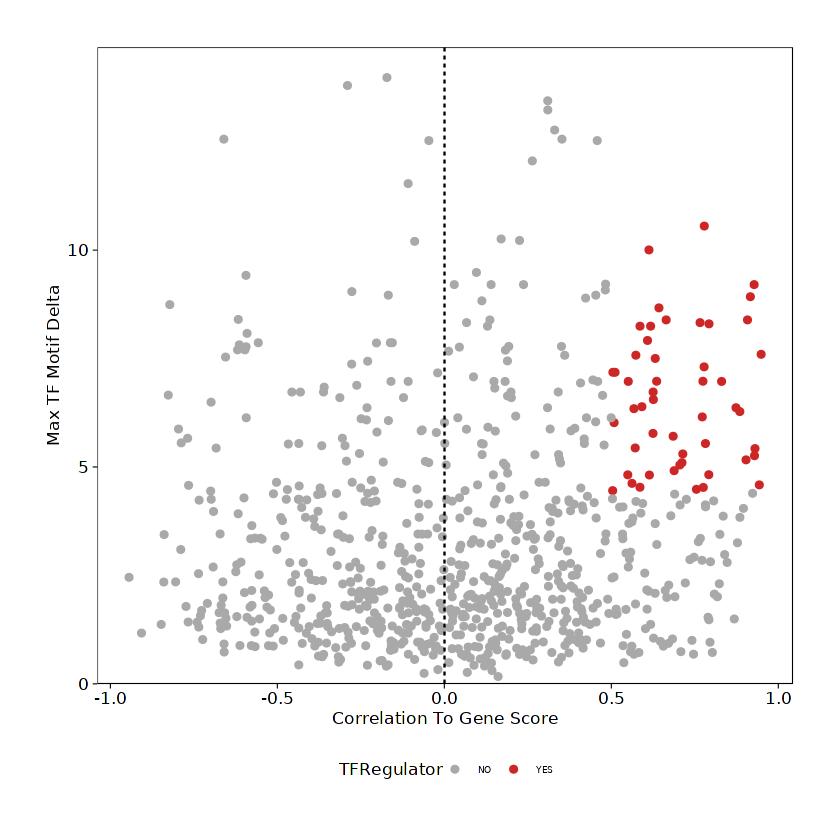

In [98]:
p <- ggplot(data.frame(corGSM_MM), aes(cor, maxDelta, color = TFRegulator)) +
  geom_point() + 
  theme_ArchR() +
  geom_vline(xintercept = 0, lty = "dashed") + 
  scale_color_manual(values = c("NO"="darkgrey", "YES"="firebrick3")) +
  xlab("Correlation To Gene Score") +
  ylab("Max TF Motif Delta") +
  scale_y_continuous(
    expand = c(0,0), 
    limits = c(0, max(corGSM_MM$maxDelta)*1.05)
  )

p

Warning message:
“Removed 63 rows containing missing values (geom_point).”


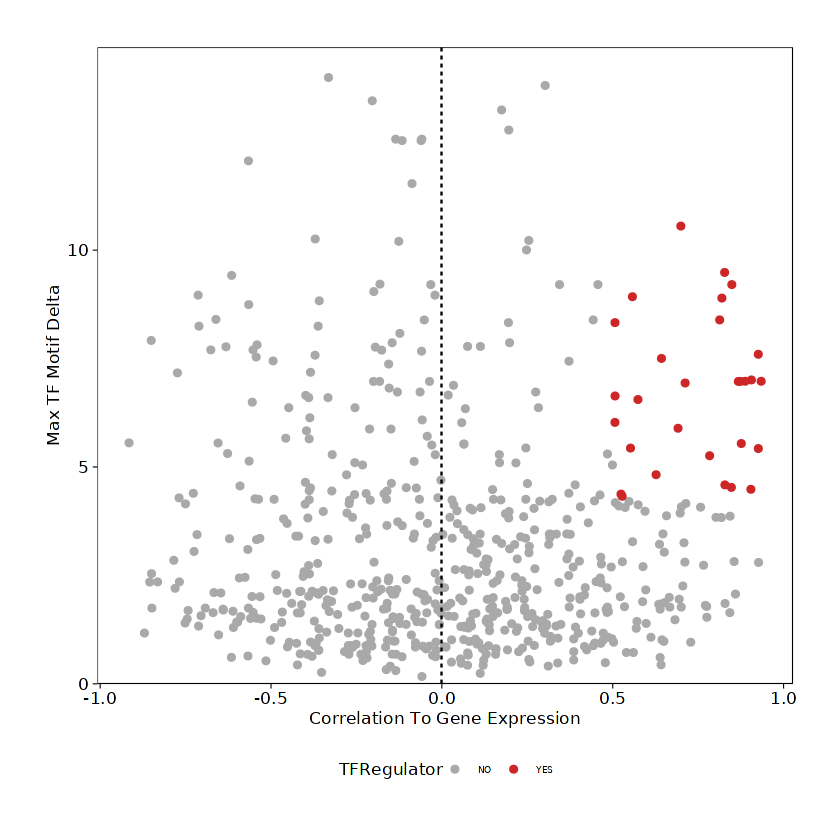

In [99]:
p <- ggplot(data.frame(corGIM_MM), aes(cor, maxDelta, color = TFRegulator)) +
  geom_point() + 
  theme_ArchR() +
  geom_vline(xintercept = 0, lty = "dashed") + 
  scale_color_manual(values = c("NO"="darkgrey", "YES"="firebrick3")) +
  xlab("Correlation To Gene Expression") +
  ylab("Max TF Motif Delta") +
  scale_y_continuous(
    expand = c(0,0), 
    limits = c(0, max(corGIM_MM$maxDelta)*1.05)
  )

p

# Trajectory Analysis

## Look at cluster distribution

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-52ae158bd93-Date-2022-09-03_Time-12-47-14.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-52ae158bd93-Date-2022-09-03_Time-12-47-14.log

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-52ae7bbae3a9-Date-2022-09-03_Time-12-47-14.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-52ae7bbae3a9-Date-2022-09-03_Time-12-47-14.log



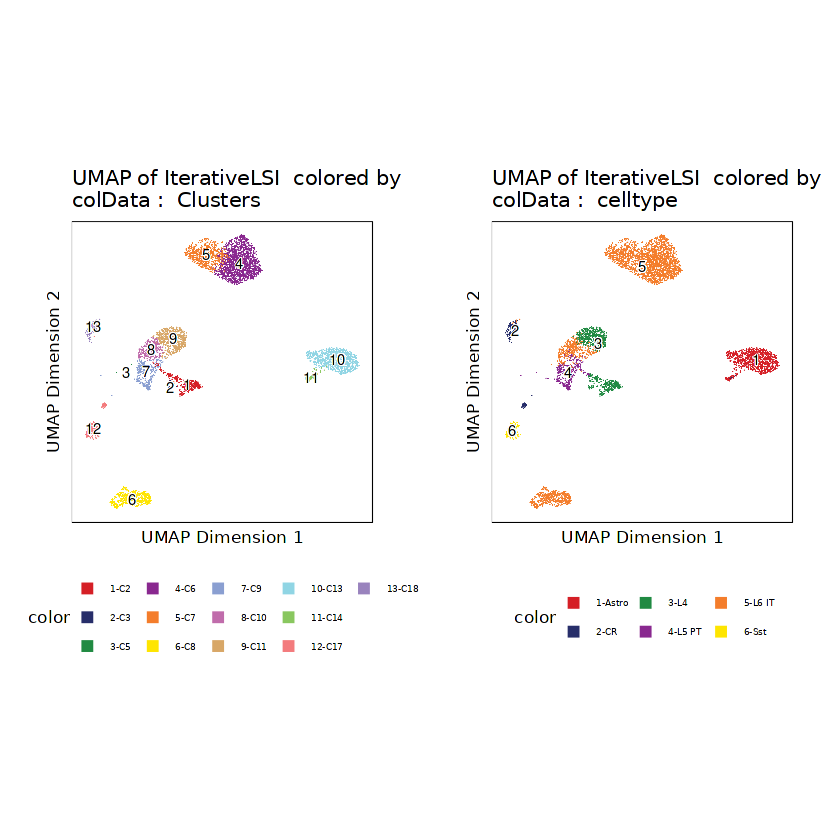

In [101]:
p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Clusters", embedding = "UMAP")
p2 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "celltype", embedding = "UMAP")
ggAlignPlots(p1, p2, type = "h")

> The only big cluster is 2-3-4-5

## Give a probable trajectory

In [105]:
trajectory <- c("CR","L4","L5 PT","L6 IT")

## Add trajectory

In [106]:
projLs <- addTrajectory(
    ArchRProj = proj, 
    name = "BrainLayer", 
    groupBy = "celltype",
    trajectory = trajectory, 
    embedding = "UMAP", 
    force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addTrajectory-52ae419d1862-Date-2022-09-03_Time-13-00-26.log
If there is an issue, please report to github with logFile!

Filtering outliers

Initial Alignment Before Spline Fit

Spline Fit

KNN to Spline

ArchR logging successful to : ArchRLogs/ArchR-addTrajectory-52ae419d1862-Date-2022-09-03_Time-13-00-26.log



## Plot trajectory

ArchR logging to : ArchRLogs/ArchR-plotTrajectory-52ae15358345-Date-2022-09-03_Time-13-00-47.log
If there is an issue, please report to github with logFile!

Plotting

Warning message:
“Removed 1560 rows containing non-finite values (stat_summary_hex).”
Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-52ae15358345-Date-2022-09-03_Time-13-00-47.log

Warning message:
“Removed 1560 rows containing non-finite values (stat_summary_hex).”


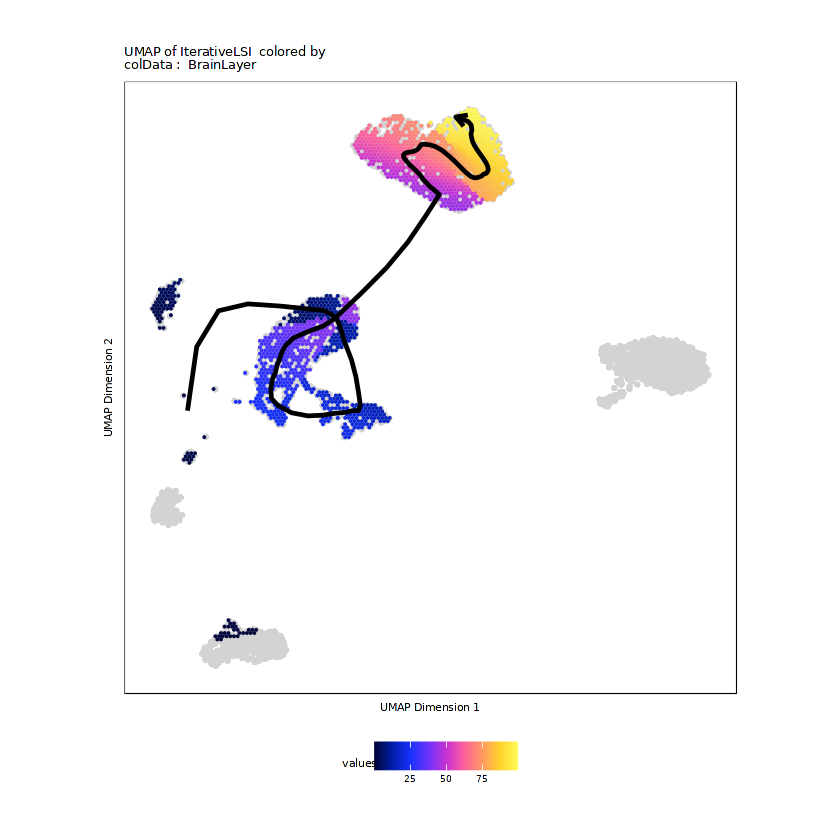

In [107]:
p <- plotTrajectory(projLs, trajectory = "BrainLayer", colorBy = "cellColData", name = "BrainLayer")
p[[1]]

### Plot gene expression changes

> MAP2 is a pyramidal cell marker gene

In [120]:
p1 <- plotTrajectory(projLs, trajectory = "BrainLayer", colorBy = "GeneScoreMatrix", name = "MAP2", continuousSet = "horizonExtra") 

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotTrajectory-52ae4c13aad5-Date-2022-09-03_Time-13-13-10.log
If there is an issue, please report to github with logFile!

Getting Matrix Values...

2022-09-03 13:13:10 : 

1 


Imputing Matrix

Using weights on disk

Using weights on disk

Plotting

Warning message:
“Removed 1560 rows containing non-finite values (stat_summary_hex).”
Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-52ae4c13aad5-Date-2022-09-03_Time-13-13-10.log



In [121]:
p2 <- plotTrajectory(projLs, trajectory = "BrainLayer", colorBy = "GeneIntegrationMatrix", name = "MAP2", continuousSet = "blueYellow")

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotTrajectory-52ae1c4bc3a0-Date-2022-09-03_Time-13-13-13.log
If there is an issue, please report to github with logFile!

Getting Matrix Values...

2022-09-03 13:13:13 : 

1 


Imputing Matrix

Using weights on disk

Using weights on disk

Plotting

Warning message:
“Removed 1560 rows containing non-finite values (stat_summary_hex).”
Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-52ae1c4bc3a0-Date-2022-09-03_Time-13-13-13.log



Warning message:
“Removed 1560 rows containing non-finite values (stat_summary_hex).”
Warning message:
“Removed 1560 rows containing non-finite values (stat_summary_hex).”


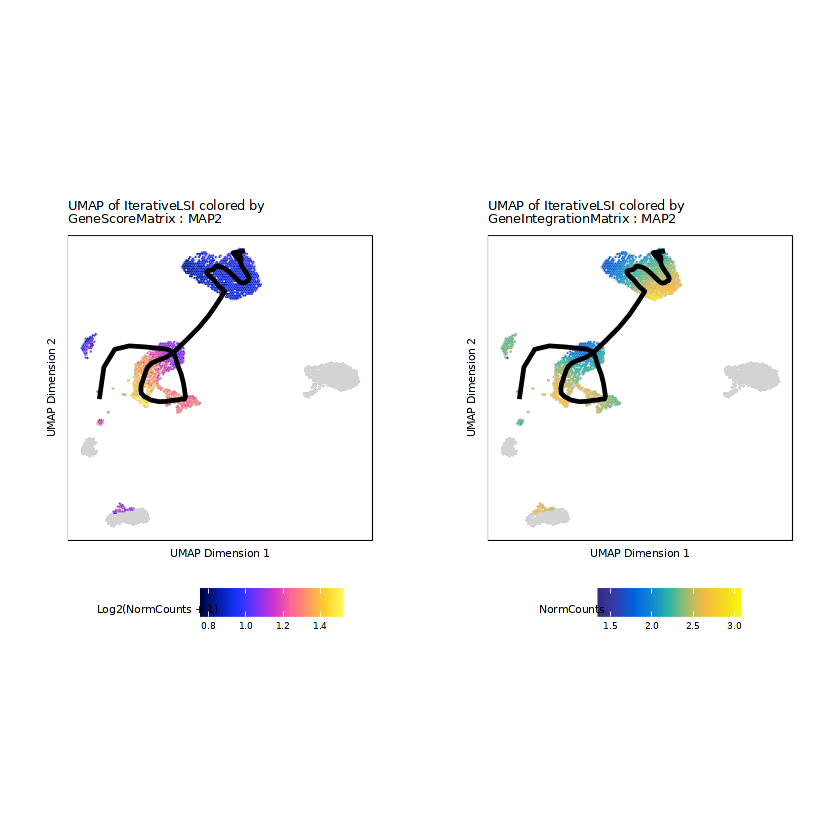

In [122]:
ggAlignPlots(p1[[1]], p2[[1]], type = "h") 

## Plot heatmap of feature change over time

In [123]:
trajMM <- getTrajectory(ArchRProj = projLs, name = "BrainLayer", useMatrix = "MotifMatrix", log2Norm = FALSE) 
#useMatrix可使用MotifMatrix GeneScoreMatrix GeneIntegrationMatrix

Creating Trajectory Group Matrix..

Some values are below 0, this could be a DeviationsMatrix in which scaleTo should be set = NULL.
Continuing without depth normalization!

Smoothing...



ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-52ae4a7c0989-Date-2022-09-03_Time-13-14-16.log
If there is an issue, please report to github with logFile!

useSeqnames is NULL or greater than 1 with a Sparse.Assays.Matrix trajectory input.

2022-09-03 13:14:17 : 

force=FALSE thus continuing with subsetting useSeqnames = z

2022-09-03 13:14:17 : 

Preparing Main Heatmap..

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-52ae4a7c0989-Date-2022-09-03_Time-13-14-16.log



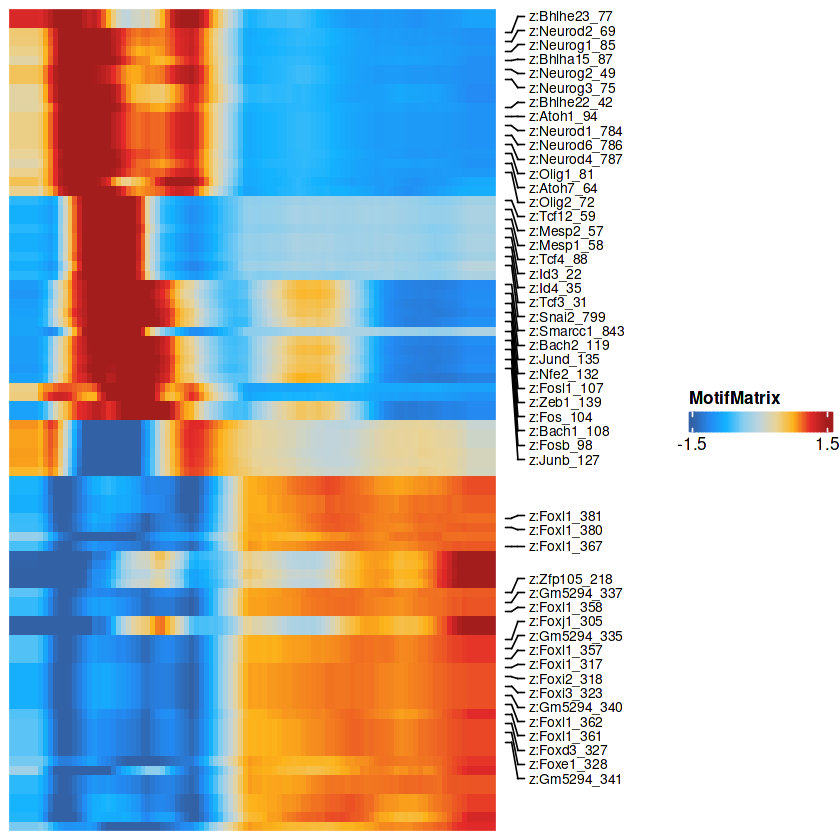

In [124]:
plotTrajectoryHeatmap(trajMM, pal = paletteContinuous(set = "solarExtra"))